In [1]:
#Output from PCM script for the solvated small-molecule

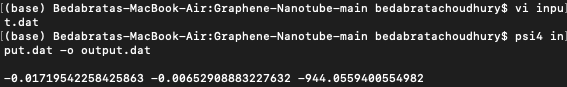

In [1]:
LUMO=-0.0171954226
HOMO=-0.006529
band_gap_solvated=(-0.006529-0.0171954226)*27.2114 
radius_0=2.28707609312783
dipole=1.8595**2.5417464519 #From output.dat file

In [2]:
from rdkit import Chem
from rdkit.Chem import Descriptors
m=Chem.MolFromMolFile('small_molecule.mol')
logp=Descriptors.MolLogP(m)

In [3]:
#Load Hydration Free Energy Model
import numpy as np
from rdkit.Chem import AllChem
from rdkit.Chem import DataStructs
import sklearn
import joblib

from rdkit.Chem import AllChem
from rdkit.Chem import DataStructs
import sklearn
import joblib

loaded_model = joblib.load('HE.sav')

X = []

arr = np.zeros((0,))
fp = AllChem.GetMorganFingerprintAsBitVect(m, 2)
DataStructs.ConvertToNumpyArray(fp, arr)
X.append(arr)

HE=loaded_model.predict(X)[0]

In [4]:
dielectric_constant_solute_solvated = 6.920*logp+(-284.010)*LUMO+ (-3.184)*HE+(107.910)*HOMO+ ( -3.748)*dipole

In [5]:
dielectric_constant_solute_solvated

29.675182749778834

In [6]:
#Calculate ground state exciton energy
eps_0=8.854*(10**(-12))
coulomb_interaction=(1.8*(1.60217663*(10**(-19)))**2)/((radius_0*(10**(-9)))*(eps_0*dielectric_constant_solute_solvated))                
coul_ev=(coulomb_interaction)*(6.242*(10**18))
exciton_energy=band_gap_solvated-coul_ev

In [7]:
exciton_energy

-1.125533068937408